# Causal Forest Feature Ablation Study (Process-Isolated Execution)

This notebook runs the Causal Forest model sequentially on 6 different feature configurations. To prevent memory Out-Of-Memory (OOM) kernel crashes when training models on 2M+ rows, each model is executed in a separate Python process. The predictions are saved to disk and aggregated in the final cell for comparison.

### Cell 1: Run Ablation Study Configurations (Process Isolation)
Runs `run_causal_config.py` in separate subprocesses to ensure memory is fully reclaimed between iterations.

In [ ]:
import sys
import subprocess

# Sequentially execute each feature ablation configuration in a fresh process
configs = ["v0", "v0_v1", "v0_v2", "v0_v3","v0_v4","v0_v1_v2_v3_v4"] 

for cfg in configs:
    print(f"\n🚀 [START] Training CausalForest for configuration: {cfg}")
    
    # Execute tools/run_causal_config.py via subprocess
    cmd = [sys.executable, "run_causal_config.py", "--config", cfg]
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode == 0:
        print(f"✅ [SUCCESS] Finished training {cfg}!")
    else:
        print(f"💥 [ERROR] Failed training {cfg} (Exit Code: {result.returncode})")
        print("\n--- ERROR LOGS ---")
        print(result.stderr)
        break
print("\n[*] All configurations executed. Proceed to the next cell to plot results.")


🚀 [START] Training CausalForest for configuration: v0_v1_v2_v3_v4


### Cell 2: Aggregate CATE Predictions & Plot Comparison Curves
Loads all saved CATE estimates from disk and renders the combined Gain, Qini, and Lift comparison curves with a clean, academic whitegrid layout.

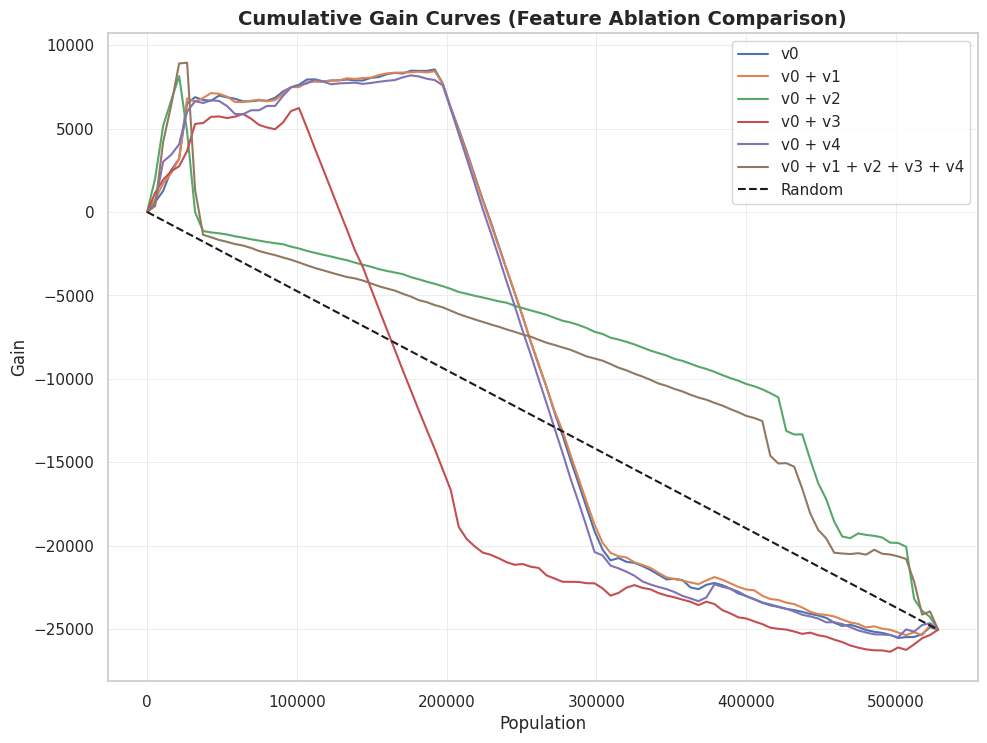

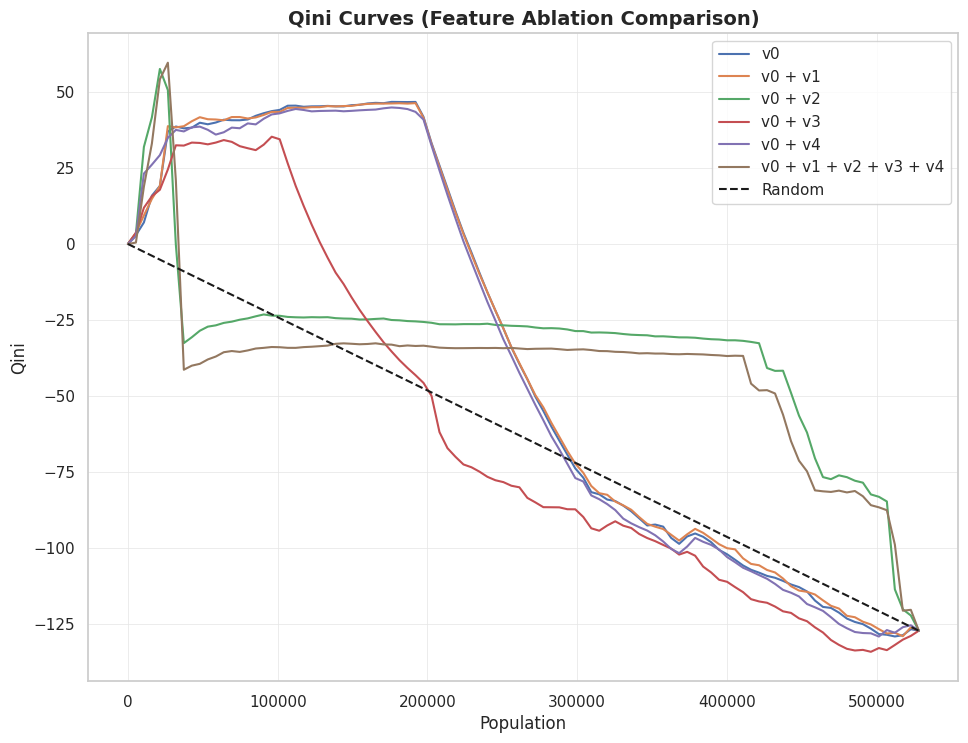

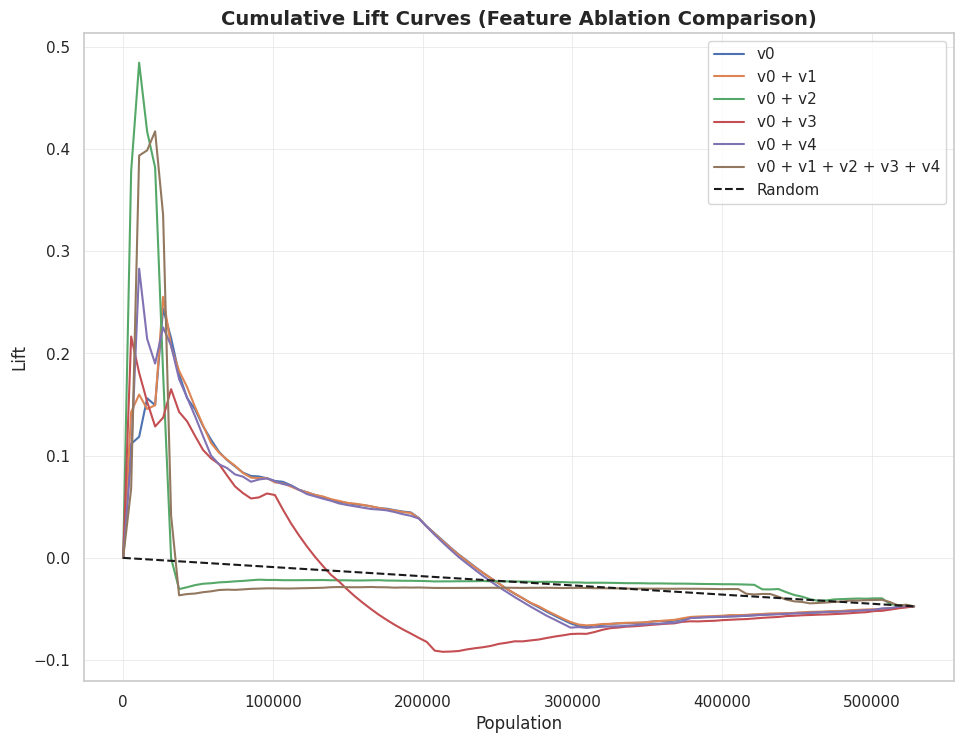

🎉 All comparison curves have been rendered successfully!


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from causalml.metrics import plot_gain, plot_qini, plot_lift

OUTPUT_DIR = "results/comparison_ab"

# Enforce whitegrid style configuration to ensure clean background rendering
def apply_academic_style(fig, ax):
    sns.set_theme(style="whitegrid")
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.grid(True, color='#E5E5E5', linestyle='-', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_color('#CCCCCC')

# Load test targets
Y_test = np.load(os.path.join(OUTPUT_DIR, "y_test.npy"))
T_test = np.load(os.path.join(OUTPUT_DIR, "t_test.npy"))

results_data = {
    'y': Y_test.flatten().astype(float),
    't': T_test.flatten().astype(int)
}

# Load saved model predictions
configs = ["v0", "v0_v1", "v0_v2", "v0_v3", "v0_v4", "v0_v1_v2_v3_v4"]
for cfg in configs:
    clean_name = cfg.replace("_", " + ")
    results_data[clean_name] = np.load(os.path.join(OUTPUT_DIR, f"pred_{cfg}.npy"))

eval_df = pd.DataFrame(results_data).dropna().reset_index(drop=True)

# 1. Cumulative Gain Curve Comparison
plot_gain(eval_df, outcome_col='y', treatment_col='t')
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(10, 8)
apply_academic_style(fig, ax)
plt.title("Cumulative Gain Curves (Feature Ablation Comparison)", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, "causal_forest_grf_gain_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

# 2. Qini Curve Comparison
plot_qini(eval_df, outcome_col='y', treatment_col='t')
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(10, 8)
apply_academic_style(fig, ax)
plt.title("Qini Curves (Feature Ablation Comparison)", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, "causal_forest_grf_qini_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

# 3. Cumulative Lift Curve Comparison
plot_lift(eval_df, outcome_col='y', treatment_col='t')
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(10, 8)
apply_academic_style(fig, ax)
plt.title("Cumulative Lift Curves (Feature Ablation Comparison)", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, "causal_forest_grf_lift_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

print("🎉 All comparison curves have been rendered successfully!")